In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os, sys

### 데이터 컬럼 정보

train.csv
  - ID: 실제 판매되고 있는 고유 ID
  - 제품: 제품 코드
  - 대분류: 제품의 대분류 코드
  - 중분류: 제품의 중분류 코드
  - 소분류: 제품의 소분류 코드
  - 2022-01-01 ~ 2023-04-04 : 실제 일별 판매량

sample_submission.csv
  - ID: 실제 판매되고 있는 고유 ID
  - 2023-04-05 ~ 2023-04-25 : 예측한 일별 판매량

sales.csv
  - ID : 실제 판매되고 있는 고유 ID
  - 제품 : 제품 코드
  - 대분류 : 제품의 대분류 코드
  - 중분류 : 제품의 중분류 코드
  - 소분류 : 제품의 소분류 코드
  - 브랜드 : 제품의 브랜드 코드
  - 2022-01-01 ~ 2023-04-04 : 실제 일별 총 판매금액

brand_keyword_cnt.csv
  - 브랜드 : 브랜드 코드
  - 2022-01-01 ~ 2023-04-04 : 브랜드의 연관키워드 언급량을 정규화한 일별 데이터

product_info.csv
  - 제품 : 제품 코드
  - 제품특성 : 제품 특성 데이터(Text)


In [2]:
# CSV 파일을 불러오기
data_path = "C:/Users/KimDongyoung/data/open (2)/train.csv"  # 원하는 파일 경로로 수정하세요
df = pd.read_csv(data_path)
df.head()

,ID,제품,대분류,중분류,소분류,브랜드,2022-01-01,2022-01-02,2022-01-03,2022-01-04,...,2023-03-26,2023-03-27,2023-03-28,2023-03-29,2023-03-30,2023-03-31,2023-04-01,2023-04-02,2023-04-03,2023-04-04
0,0,B002-00001-00001,B002-C001-0002,B002-C002-0007,B002-C003-0038,B002-00001,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,B002-00002-00001,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,0,0,0,0,...,0,0,0,1,3,2,0,0,2,0
2,2,B002-00002-00002,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3,B002-00002-00003,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,B002-00003-00001,B002-C001-0001,B002-C002-0001,B002-C003-0003,B002-00003,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
train = pd.read_csv(os.path.join("C:/Users/KimDongyoung/data/open (2)/", 'train.csv'))
sample_submission = pd.read_csv(os.path.join("C:/Users/KimDongyoung/data/open (2)/", 'sample_submission.csv'))
sales = pd.read_csv(os.path.join("C:/Users/KimDongyoung/data/open (2)/", 'sales.csv'))
product_info = pd.read_csv(os.path.join("C:/Users/KimDongyoung/data/open (2)/", 'product_info.csv'))
brand_keyword_cnt = pd.read_csv(os.path.join("C:/Users/KimDongyoung/data/open (2)/", 'brand_keyword_cnt.csv'))

In [8]:
train['제품'].value_counts()

제품
B002-00070-00009    2
B002-01083-00002    2
B002-03481-00001    2
B002-03796-00008    2
B002-01523-00045    2
                   ..
B002-01277-00015    1
B002-01277-00016    1
B002-01277-00017    1
B002-01277-00018    1
B002-03799-00010    1
Name: count, Length: 15840, dtype: int64

In [11]:
brand_keyword_cnt['브랜드'].nunique()

3170

In [6]:
train['제품'].isna().sum()

0

In [12]:
# 각 데이터셋의 key(조인 기준이 될 수 있는 컬럼) 확인
print("train columns:", train.columns)
print("sales columns:", sales.columns)
print("product_info columns:", product_info.columns)
print("brand_keyword_cnt columns:", brand_keyword_cnt.columns)
print("sample_submission columns:", sample_submission.columns)

# 조인 기준이 될 수 있는 컬럼 정리
# - train, sales: ['ID', '제품', '대분류', '중분류', '소분류', '브랜드']
# - product_info: ['제품']
# - brand_keyword_cnt: ['브랜드']
# - sample_submission: ['ID']

# 따라서,
# 1. train, sales는 'ID' 또는 '제품' 등으로 조인 가능
# 2. train, sales와 product_info는 '제품'으로 조인 가능
# 3. train, sales와 brand_keyword_cnt는 '브랜드'로 조인 가능
# 4. train, sales와 sample_submission은 'ID'로 조인 가능

# 예시 출력
print("""
조인 가능한 데이터셋:
- train, sales: 'ID', '제품', '대분류', '중분류', '소분류', '브랜드'
- train, sales, product_info: '제품'
- train, sales, brand_keyword_cnt: '브랜드'
- train, sales, sample_submission: 'ID'
""")

train columns: Index(['ID', '제품', '대분류', '중분류', '소분류', '브랜드', '2022-01-01', '2022-01-02',
       '2022-01-03', '2022-01-04',
       ...
       '2023-03-26', '2023-03-27', '2023-03-28', '2023-03-29', '2023-03-30',
       '2023-03-31', '2023-04-01', '2023-04-02', '2023-04-03', '2023-04-04'],
      dtype='object', length=465)
sales columns: Index(['ID', '제품', '대분류', '중분류', '소분류', '브랜드', '2022-01-01', '2022-01-02',
       '2022-01-03', '2022-01-04',
       ...
       '2023-03-26', '2023-03-27', '2023-03-28', '2023-03-29', '2023-03-30',
       '2023-03-31', '2023-04-01', '2023-04-02', '2023-04-03', '2023-04-04'],
      dtype='object', length=465)
product_info columns: Index(['제품', '제품특성'], dtype='object')
brand_keyword_cnt columns: Index(['브랜드', '2022-01-01', '2022-01-02', '2022-01-03', '2022-01-04',
       '2022-01-05', '2022-01-06', '2022-01-07', '2022-01-08', '2022-01-09',
       ...
       '2023-03-26', '2023-03-27', '2023-03-28', '2023-03-29', '2023-03-30',
       '2023-03-31', '2023-0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15890 entries, 0 to 15889
Columns: 465 entries, ID to 2023-04-04
dtypes: int64(460), object(5)
memory usage: 56.4+ MB
None
                 ID    2022-01-01    2022-01-02   2022-01-03    2022-01-04  \
count  15890.000000  15890.000000  15890.000000  15890.00000  15890.000000   
mean    7944.500000     12.887476     10.418880      9.01309      9.190938   
std     4587.192224    183.612376    149.663362     95.82452     86.274138   
min        0.000000      0.000000      0.000000      0.00000      0.000000   
25%     3972.250000      0.000000      0.000000      0.00000      0.000000   
50%     7944.500000      0.000000      0.000000      0.00000      0.000000   
75%    11916.750000      0.000000      0.000000      0.00000      0.000000   
max    15889.000000  15056.000000  14320.000000   6064.00000   4470.000000   

         2022-01-05    2022-01-06    2022-01-07    2022-01-08    2022-01-09  \
count  15890.000000  15890.000000  15890.0000

c:\Users\KimDongyoung\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 54032 (\N{HANGUL SYLLABLE PAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\KimDongyoung\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\KimDongyoung\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\KimDongyoung\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\KimDongyoung\AppData\Local\Progr

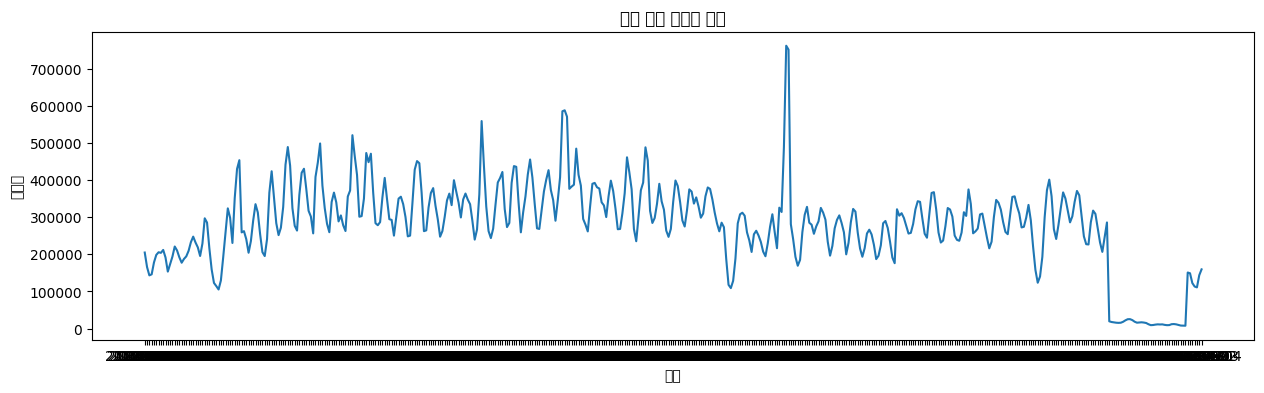

In [15]:
# EDA(탐색적 데이터 분석) 기본 흐름 예시

# 1. 데이터 기본 정보 확인
# print("train shape:", train.shape)
# print("train columns:", train.columns)
print(train.info())
print(train.describe())

# 2. 결측치 및 이상치 탐색
# print("결측치 개수:\n", train.isnull().sum())
# print("중복 데이터 개수:", train.duplicated().sum())

# 3. 주요 컬럼별 분포 확인
print("제품 수:", train['제품'].nunique())
print("브랜드 수:", train['브랜드'].nunique())
print("대분류 수:", train['대분류'].nunique())
print("중분류 수:", train['중분류'].nunique())
print("소분류 수:", train['소분류'].nunique())

# # 4. 일별 판매량 통계 및 시각화
date_cols = train.columns[6:]  # 날짜 컬럼만 추출
daily_sales = train[date_cols].sum()
plt.figure(figsize=(15,4))
plt.plot(daily_sales)
plt.title('전체 일별 판매량 추이')
plt.xlabel('날짜')
plt.ylabel('판매량')
plt.show()

# # 5. 카테고리별(브랜드, 대분류 등) 판매량 집계 및 시각화
# brand_sales = train.groupby('브랜드')[date_cols].sum().sum(axis=1).sort_values(ascending=False)
# plt.figure(figsize=(10,4))
# sns.barplot(x=brand_sales.index[:10], y=brand_sales.values[:10])
# plt.title('브랜드별 총 판매량 Top 10')
# plt.xlabel('브랜드')
# plt.ylabel('총 판매량')
# plt.show()

# # 6. 제품 특성 데이터와의 연계 탐색
# print(product_info.head())

# 7. 기타: 상관관계, 시즌성, 트렌드 등 추가 분석
# 예: 월별/요일별 집계, 상관관계 heatmap 등

# 위의 예시를 참고해 원하는 방향으로 세부 분석을 추가하면 됩니다.

C:\Users\KimDongyoung\AppData\Local\Temp\ipykernel_7192\1660650447.py:12: UserWarning: Glyph 45216 (\N{HANGUL SYLLABLE NAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KimDongyoung\AppData\Local\Temp\ipykernel_7192\1660650447.py:12: UserWarning: Glyph 51676 (\N{HANGUL SYLLABLE JJA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KimDongyoung\AppData\Local\Temp\ipykernel_7192\1660650447.py:12: UserWarning: Glyph 54032 (\N{HANGUL SYLLABLE PAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KimDongyoung\AppData\Local\Temp\ipykernel_7192\1660650447.py:12: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KimDongyoung\AppData\Local\Temp\ipykernel_7192\1660650447.py:12: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KimDongyoung\AppData\Local\Temp\ipykernel_7192\1660650447.py:12: UserWarning: Glyph 51473

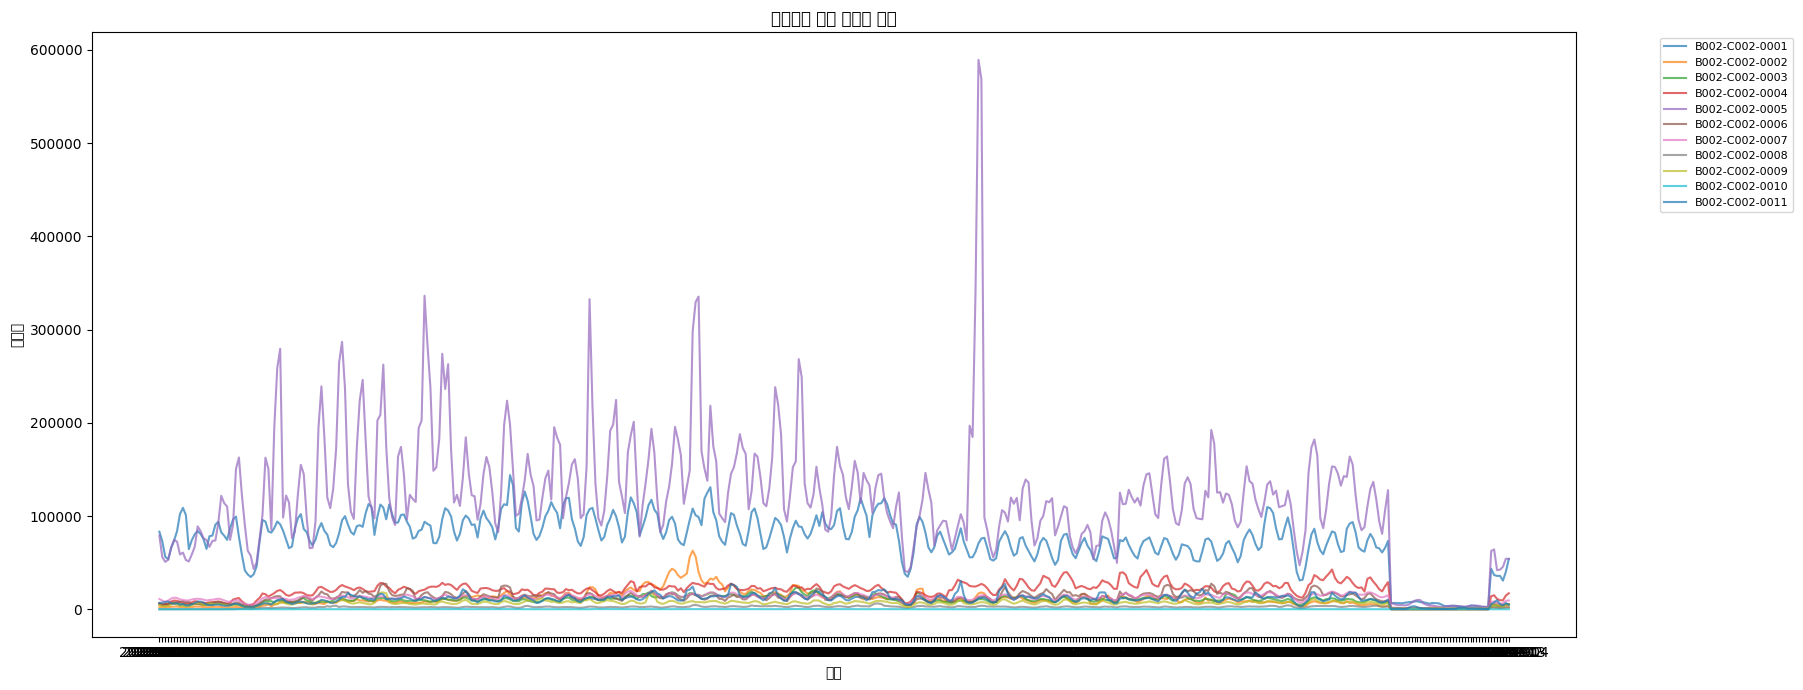

In [16]:
# 중분류별 일별 판매량 집계
middle_category_sales = train.groupby('중분류')[date_cols].sum().T

# 그래프 시각화 (중분류별 전체 추이)
plt.figure(figsize=(18, 7))
for col in middle_category_sales.columns:
  plt.plot(middle_category_sales.index, middle_category_sales[col], label=col, alpha=0.7)
plt.title('중분류별 일별 판매량 추이')
plt.xlabel('날짜')
plt.ylabel('판매량')
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1), ncol=1, fontsize=8)
plt.tight_layout()
plt.show()

In [16]:
sample_submission.head()
# train.head()
# sales.head()

,ID,2023-04-05,2023-04-06,2023-04-07,2023-04-08,2023-04-09,2023-04-10,2023-04-11,2023-04-12,2023-04-13,...,2023-04-16,2023-04-17,2023-04-18,2023-04-19,2023-04-20,2023-04-21,2023-04-22,2023-04-23,2023-04-24,2023-04-25
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [17]:
sales.columns

Index(['ID', '제품', '대분류', '중분류', '소분류', '브랜드', '2022-01-01', '2022-01-02',
       '2022-01-03', '2022-01-04',
       ...
       '2023-03-26', '2023-03-27', '2023-03-28', '2023-03-29', '2023-03-30',
       '2023-03-31', '2023-04-01', '2023-04-02', '2023-04-03', '2023-04-04'],
      dtype='object', length=465)

In [23]:
brand_keyword_cnt['브랜드'].nunique()
sales['브랜드'].nunique()
train['브랜드'].nunique()

3170

In [19]:
brand_keyword_cnt.head()

,브랜드,2022-01-01,2022-01-02,2022-01-03,2022-01-04,2022-01-05,2022-01-06,2022-01-07,2022-01-08,2022-01-09,...,2023-03-26,2023-03-27,2023-03-28,2023-03-29,2023-03-30,2023-03-31,2023-04-01,2023-04-02,2023-04-03,2023-04-04
0,B002-00001,0.84131,0.91383,1.450530,2.422390,1.871190,1.581080,1.232950,1.174930,1.145920,...,0.319110,0.391640,0.377130,0.49318,0.072520,0.29010,0.31911,0.232080,0.333620,0.44966
1,B002-00002,12.64868,20.27850,15.332170,12.750210,13.562510,13.707570,11.937910,15.564250,14.084710,...,10.269790,11.966920,10.646930,10.41485,10.487380,9.48651,9.28343,10.429350,11.154620,11.38671
2,B002-00003,0.33362,0.43516,0.362630,0.174060,0.217580,0.464170,0.420650,0.290100,0.377130,...,0.536690,0.696250,0.449660,0.39164,1.029880,0.49318,0.91383,0.797790,1.015370,0.88482
3,B002-00005,1.07339,1.71163,2.016240,1.914700,1.987230,2.146790,1.682620,1.378000,1.421520,...,2.219320,2.509420,2.872060,2.37888,2.030750,1.53756,1.34899,1.261960,2.320850,2.30635
4,B002-00006,0.00000,0.00000,0.188558,0.246574,0.246574,0.246574,0.377139,0.087012,0.261084,...,0.072526,0.290103,0.087012,0.00000,0.130542,0.00000,0.00000,0.072526,0.217577,0.00000


In [18]:
product_info.head()

,제품,제품특성
0,B002-03509-00001,제품유형:일반식품 콜라겐 펩타이드:1000mg 종류:어류 분자량:300Da 섭취대상...
1,B002-02376-00001,700mg x 28정
2,B002-03735-00001,제품타입:정 섭취방법:물과 함께 섭취대상:성인남녀 섭취횟수:하루 두 번 1일 총 섭...
3,B002-03735-00003,제품타입:정 섭취방법:물과 함께 섭취대상:성인남녀 섭취횟수:하루 한 번 1일 총 섭...
4,B002-02769-00001,HCA:900mg 영양소 원료명(식약처고시):비타민B1 영양소 원료명(식약처고시):...
